The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


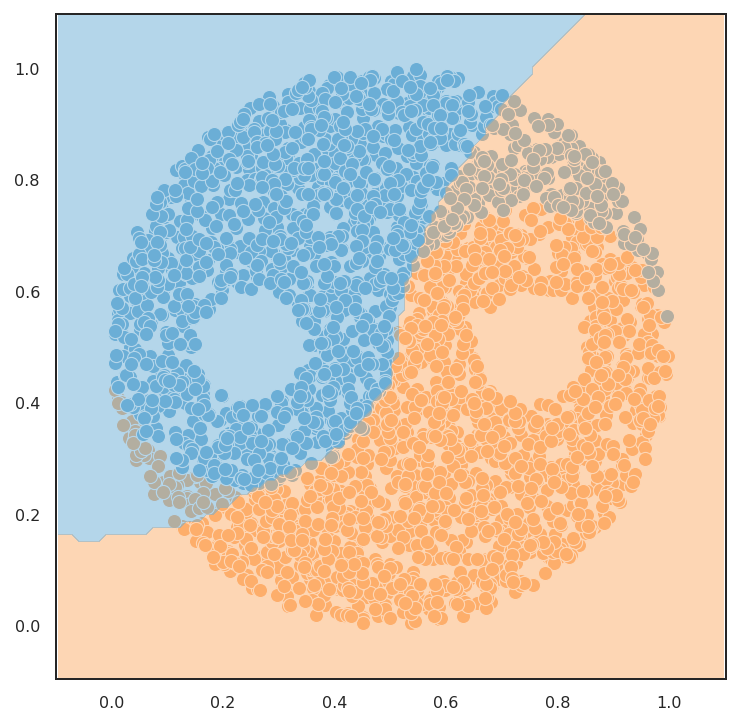

In [15]:
import os
import sys
from copy import deepcopy
from pathlib import Path

import einops
import matplotlib.pyplot as plt
import numpy as np
import panel as pn
import pykoopman as pk
import scipy
import seaborn as sns
import torch
from jaxtyping import Float, Int
from matrepr import mdisplay, mprint
from pydmd import DMD
from rich import print as rprint
from torch import Tensor, nn, optim
from torch.nn.functional import mse_loss
from torch.optim import LBFGS, Adam

from analysis.koopman import KoopmanWrapper
from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    get_dataset_class,
)
from nnscaling.models import MLP, ScaledModel
from nnscaling.trajectory import TrajectoryEngine, reshape_append_time
from nnscaling.utils import compute_model_accuracy
from nnscaling.visualization import plot_decision_boundary, plot_eigenvalues

%load_ext autoreload
%autoreload 2


In [16]:
NUM_TRAJ = 1_500  # Try to keep below 3_000
BATCH_SIZE = 5_000  # Number of Koopman inferences to run at once
DELAY_PARAM = 10  # Typically set to iterations - 2

In [17]:
# Project directory
project_dir = Path(os.getcwd()).parent

# Load original model
file_path = Path(project_dir, "model_saves/yinyang_model.safetensors")
original_model = MLP.load_model(file_path).eval()

# Load scaled model
file_path = Path(project_dir, "model_saves/scaling/loc_1_scaled_yinyang_model.safetensors")
scaled_model = ScaledModel.load_model(original_model, file_path).eval()

# Dataset config
dataset_config = DatasetConfig(
    dataset_name="YinYangNoDotsBinaryDataset",
    num_samples=3_000,
    split="train",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
dataset = DatasetClass(config=dataset_config)

In [18]:
# Generate trajectories
trajectory_engine = TrajectoryEngine(
    dataset_config=dataset_config,
    scaled_model=scaled_model,
)
acts_dict = trajectory_engine.generate_trajectory(
    num_train=NUM_TRAJ,
    magic_number=-0.5,
    seed=0,
)

# Train states
train_states = acts_dict["scaled_train"]
train_states = reshape_append_time(acts_dict["scaled_train"])

test_states = acts_dict["scaled_test"]

In [19]:
observable_fn = pk.observables.TimeDelay(delay=1, n_delays=DELAY_PARAM)
regressor = pk.regression.EDMD(svd_rank=110)
# regressor = DMD()

dmd_model = pk.Koopman(observables=observable_fn, regressor=regressor)
dmd_model.fit(train_states.numpy().T)

koopman_scaled_model = KoopmanWrapper(scaled_model, dmd_model=dmd_model, n_delays=DELAY_PARAM)

In [20]:
###############
# FOR PROTOTYPE
tensor_A = torch.from_numpy(deepcopy(dmd_model.A)).float()
tensor_lamda = torch.from_numpy(deepcopy(dmd_model.lamda))
frozen_lamda = torch.from_numpy(deepcopy(dmd_model.lamda))
tensor_V = torch.from_numpy(deepcopy(dmd_model._regressor_eigenvectors))
tensor_V_inv = torch.linalg.inv(tensor_V)
tensor_B = torch.eye(tensor_A.shape[0])
tensor_C = torch.from_numpy(dmd_model.C).float()

tensor_mm = torch.from_numpy(dmd_model.observables.measurement_matrix_).float()
tensor_ur = torch.from_numpy(dmd_model.regressor.ur).float()
###############


In [21]:
def simulate_lamda(x0, n_steps):
    if isinstance(x0, torch.Tensor):
        x0 = x0.numpy()

    # NOTE: Time-delay embedding (TDE) on the batched input tensor
    # returns tensor `Hx` with shape [batch iteration feature],
    # where feature is a spatio-temporal dimension.
    # PyKooopman's time delay observable is NOT batched; it returns [feature iteration].
    x0 = x0[:, :, : DELAY_PARAM + 1]
    tensor_obs = koopman_scaled_model._tde(x0).float()

    # NOTE: The original implementation computes U.T @ Hx.
    # However, because X is batched, we compute (U.T @ H.x).T = H.x.T @ U
    # taking a page from the F.linear book. This keeps the batch dimension intact
    y = tensor_obs @ tensor_ur

    # Flatten to [batch, RSV]
    # y = tensor_ur.T.flatten(start_dim=0, end_dim=1).T
    y = y.flatten(start_dim=1).to(torch.complex64)
    y = y @ tensor_V_inv.conj().T

    y_steps = []
    # Step forward and return to original space
    # NOTE: We use the transpose matmult to preserve batch
    for _ in range(n_steps):
        y = y @ tensor_lamda.conj()
        y_steps.append(y)

    y = torch.stack(y_steps, dim=0) @ tensor_V.conj().T

    # Return back from observable space
    y = y.float() @ tensor_C.T

    # Rearrange for standard order
    y = einops.rearrange(y, "iteration batch state -> batch state iteration")

    return y

In [22]:
koopman_scaled_model.simulate = simulate_lamda

In [23]:
pn.extension()

# Initialize dummy eigenvalues
eigenvalues = tensor_lamda


# Dummy function to compute the next state (replace with your actual function)
def compute_next_state(eigenvalues):
    return None


# Dummy function to plot the geometric object
def plot_geometric_object(next_state):
    plt.close("all")
    plot_decision_boundary(
        koopman_scaled_model,
        koopman_scaled_model.state_dict(),
        dataset.features,
        dataset.labels.squeeze(),
        labels=[0, 1],
    )
    return plt.gcf()  # Return the current figure

Launching server at http://localhost:37297


/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")


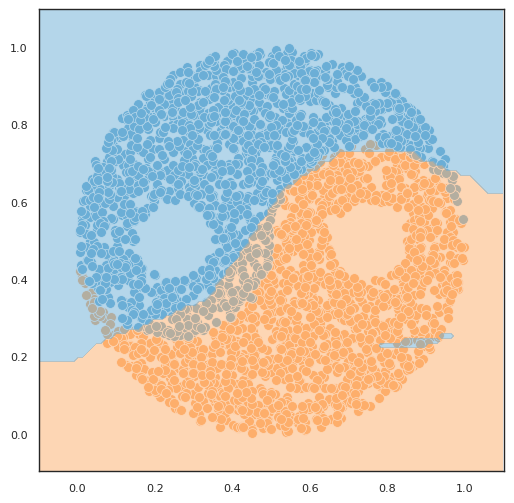

/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")
/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")
/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")
/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")
/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")
/home/nsa3

In [ ]:
# Create input box for index and slider for eigenvalue
index_input = pn.widgets.IntInput(name="Index", value=0, start=0, end=eigenvalues.shape[0] - 1)
real_slider = pn.widgets.FloatSlider(
    name="Real",
    start=-3,
    end=3,
    step=0.01,
    # value=eigenvalues[index_input.value][index_input.value].real.item(),
    value=0,
)
imag_slider = pn.widgets.FloatSlider(
    name="Imaginary",
    start=-3,
    end=3,
    step=0.01,
    # value=eigenvalues[index_input.value][index_input.value].imag.item(),
    value=0,
)


# Function to update the eigenvalue and plot the geometric object
def update_plot(event=None):
    idx = int(index_input.value)
    real_value = torch.tensor(real_slider.value).float()
    imag_value = torch.tensor(imag_slider.value).float()
    eigenvalues[idx][idx] = torch.complex(real_value, imag_value)
    # next_state = compute_next_state(eigenvalues)
    plot_pane.object = plot_geometric_object(None)


# Update plot when inputs change
index_input.param.watch(update_plot, "value")
real_slider.param.watch(update_plot, "value_throttled")
imag_slider.param.watch(update_plot, "value_throttled")

# Initial plot
plot_pane = pn.pane.Matplotlib(plot_geometric_object(compute_next_state(eigenvalues)), tight=True)

# Improved layout with centered and spaced elements
layout = pn.Column(
    pn.Row(index_input, align="center", margin=(10, 20)),
    pn.Row(real_slider, imag_slider, align="center", margin=(10, 20)),
    plot_pane,
    align="center",
    margin=(20, 100),
)

layout.show()

In [25]:
print(torch.diag(frozen_lamda))

tensor([ 9.9972e-01+0.0000j,  8.6527e-01+0.4994j,  8.6527e-01-0.4994j,
        -9.9966e-01+0.0000j,  4.9939e-01+0.8654j,  4.9939e-01-0.8654j,
         8.5853e-01+0.0364j,  8.5853e-01-0.0364j,  8.3075e-01+0.1449j,
         8.3075e-01-0.1449j, -1.2383e-04+0.9983j, -1.2383e-04-0.9983j,
         8.2096e-01+0.2586j,  8.2096e-01-0.2586j,  7.8971e-01+0.0000j,
         7.5956e-01+0.4214j,  7.5956e-01-0.4214j,  7.7930e-01+0.3182j,
         7.7930e-01-0.3182j,  7.8924e-01+0.2533j,  7.8924e-01-0.2533j,
        -8.6532e-01+0.4994j, -8.6532e-01-0.4994j,  6.8180e-01+0.5064j,
         6.8180e-01-0.5064j,  7.1724e-01+0.3129j,  7.1724e-01-0.3129j,
         7.1670e-01+0.0818j,  7.1670e-01-0.0818j,  6.5770e-01+0.5048j,
         6.5770e-01-0.5048j,  6.1620e-01+0.5888j,  6.1620e-01-0.5888j,
        -4.9980e-01+0.8657j, -4.9980e-01-0.8657j,  5.0072e-01+0.7246j,
         5.0072e-01-0.7246j,  5.5639e-01+0.6110j,  5.5639e-01-0.6110j,
         5.0382e-01+0.6479j,  5.0382e-01-0.6479j,  3.6276e-01+0.7880j,
      

tensor([ 0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.5564+0.6110j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.3628+0.7880j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.1711+0.8611j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,  0.0100+0.0000j,
         0.0

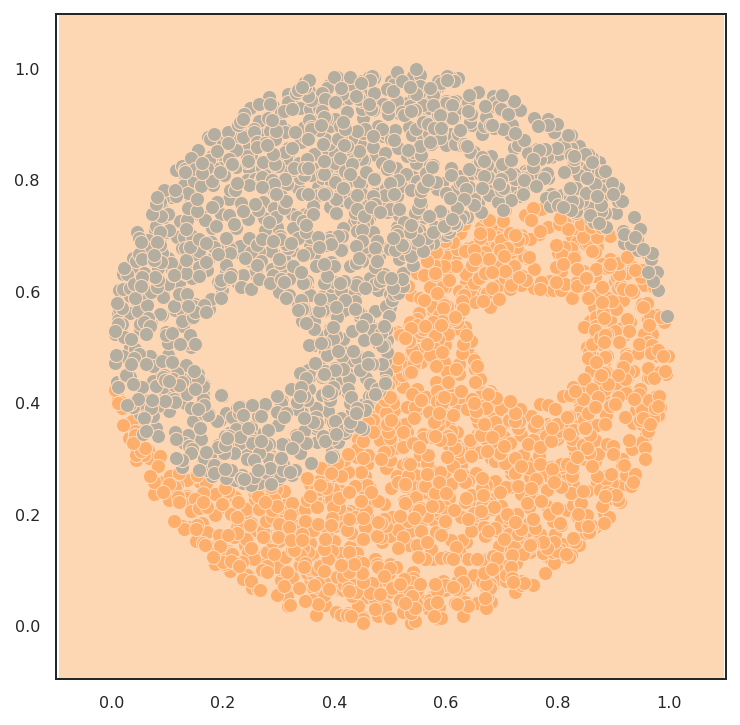

In [28]:
print(torch.diag(tensor_lamda))